# Laboratorio 7 – Regresión Logística

## 0. Configuración — Pipeline de Labs 4–6

In [24]:
import pyreadr, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import time, warnings, tracemalloc, cProfile, pstats, io
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
    StratifiedKFold, learning_curve, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, log_loss)
from sklearn.pipeline import Pipeline
from scipy import stats
import statsmodels.api as sm

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

In [25]:
# Pipeline idéntico a Labs 4–6
result = pyreadr.read_r('listings.Rdata')
df_raw = result[list(result.keys())[0]].copy()

df = df_raw.copy()
if df['price'].dtype == object:
    df['price'] = (df['price'].str.replace(r'[\$,]','',regex=True)
                   .str.strip().replace('',np.nan).astype(float))
q_high = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()

cols_drop = ['id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_thumbnail_url','host_picture_url','host_about','host_verifications',
    'amenities','calendar_updated','calendar_last_scraped','license',
    'bathrooms_text','minimum_minimum_nights','maximum_minimum_nights',
    'minimum_maximum_nights','maximum_maximum_nights',
    'minimum_nights_avg_ntm','maximum_nights_avg_ntm']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])
null_pct = df.isnull().mean()
df = df.drop(columns=null_pct[null_pct > 0.60].index.tolist())

if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_years'] = ((pd.Timestamp('2024-01-01') - df['host_since']).dt.days/365).round(1)
    df = df.drop(columns=['host_since'])
df = df.drop(columns=[c for c in ['first_review','last_review'] if c in df.columns], errors='ignore')

for col in ['host_is_superhost','host_has_profile_pic','host_identity_verified',
            'has_availability','instant_bookable']:
    if col in df.columns:
        df[col] = df[col].map({'t':1,'f':0,True:1,False:0})
for col in ['host_response_rate','host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].str.replace('%','',regex=False).str.strip().astype(float, errors='ignore')

TARGET = 'price'
num_features = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
cat_features = [c for c in ['room_type','property_type','neighbourhood_cleansed',
                              'host_response_time'] if c in df.columns]
for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.01].index, 'Otro')
df_encoded = pd.get_dummies(df[num_features+cat_features+[TARGET]],
                             columns=cat_features, drop_first=True, dtype=int)
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

# Variables categóricas de precio (igual que Labs anteriores)
p33 = df_encoded[TARGET].quantile(0.33)  # $140
p67 = df_encoded[TARGET].quantile(0.67)  # $267
df_encoded['price_category'] = df_encoded[TARGET].apply(
    lambda p: 'Económico' if p<=p33 else ('Intermedio' if p<=p67 else 'Caro'))

feature_cols = [c for c in df_encoded.columns if c not in [TARGET,'price_category']]
X = df_encoded[feature_cols]
y_price = df_encoded[TARGET]

# Split IDÉNTICO (random_state=42, test_size=0.20) — mismo de Labs 4-6
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X, y_price, test_size=0.20, random_state=42)

print(f"Dataset: {df_encoded.shape[0]:,} filas × {len(feature_cols)} features")
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"P33=${p33:.0f}  P67=${p67:.0f}")

Dataset: 75,531 filas × 73 features
Train: 60,424  |  Test: 15,107
P33=$140  P67=$267


## Actividad 1 – Variables Dicotómicas

Se crean tres variables binarias (0/1) a partir de `price_category`, una por cada categoría.
Estas variables permiten entrenar un clasificador binario independiente para cada categoría.
Se enfoca en es_cara

- es_cara = 1 si precio > $267/noche (percentil 67), 0 en caso contrario
- es_intermedia = 1 si $140 < precio ≤ $267 (entre P33 y P67), 0 en otro caso
- es_economica = 1 si precio ≤ $140/noche (percentil 33), 0 en caso contrario


In [26]:
# La variable price_category ya fue creada en Labs anteriores.
# Aquí convertimos cada categoría en una variable binaria independiente.

df_encoded['es_cara']       = (df_encoded['price_category'] == 'Caro').astype(int)
df_encoded['es_intermedia'] = (df_encoded['price_category'] == 'Intermedio').astype(int)
df_encoded['es_economica']  = (df_encoded['price_category'] == 'Económico').astype(int)

# Verificar distribución
for var in ['es_cara','es_intermedia','es_economica']:
    n1 = df_encoded[var].sum()
    n0 = len(df_encoded) - n1
    print(f"{var:<15}: {n1:>6} positivos ({n1/len(df_encoded)*100:.1f}%)  |  {n0:>6} negativos ({n0/len(df_encoded)*100:.1f}%)")

print()
# Verificar que son mutuamente excluyentes y exhaustivas
assert (df_encoded['es_cara']+df_encoded['es_intermedia']+df_encoded['es_economica']).eq(1).all()
print("Las tres variables son mutuamente excluyentes y exhaustivas (suma siempre = 1).")
print()
print("Clase de interés: es_cara, detectar propiedades con precio > $267/noche")


es_cara        :  24809 positivos (32.8%)  |   50722 negativos (67.2%)
es_intermedia  :  25787 positivos (34.1%)  |   49744 negativos (65.9%)
es_economica   :  24935 positivos (33.0%)  |   50596 negativos (67.0%)

Las tres variables son mutuamente excluyentes y exhaustivas (suma siempre = 1).

Clase de interés: es_cara, detectar propiedades con precio > $267/noche


## Actividad 2 – Conjuntos de Entrenamiento y Prueba

In [27]:
# Variable objetivo: es_cara (clasificación binaria)
# Se usa el MISMO X_train, X_test de los Labs 4–6 (random_state=42)

y_train = df_encoded.loc[X_train.index, 'es_cara']
y_test  = df_encoded.loc[X_test.index,  'es_cara']

print(f"ENTRENAMIENTO: {len(X_train):,} filas")
print(f"  Cara (1):    {y_train.sum():>6} ({y_train.mean()*100:.1f}%)")
print(f"  No Cara (0): {(~y_train.astype(bool)).sum():>6} ({(1-y_train.mean())*100:.1f}%)")
print()
print(f"PRUEBA: {len(X_test):,} filas")
print(f"  Cara (1):    {y_test.sum():>6} ({y_test.mean()*100:.1f}%)")
print(f"  No Cara (0): {(~y_test.astype(bool)).sum():>6} ({(1-y_test.mean())*100:.1f}%)")
print()
print("Las proporciones train/test son similares, split estratificado efectivo.")

# Escalar features (necesario para Regresión Logística y KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

ENTRENAMIENTO: 60,424 filas
  Cara (1):     19930 (33.0%)
  No Cara (0):  40494 (67.0%)

PRUEBA: 15,107 filas
  Cara (1):      4879 (32.3%)
  No Cara (0):  10228 (67.7%)

Las proporciones train/test son similares, split estratificado efectivo.


## Actividad 4 – Análisis de Variables: Correlación y Multicolinealidad

Antes de entrenar el modelo logístico, analizamos las correlaciones entre features y con
la variable objetivo `es_cara`, para identificar variables predictivas y detectar multicolinealidad.


TOP 20 VARIABLES MÁS CORRELACIONADAS CON es_cara
  + accommodates                             r=0.480
  + bathrooms                                r=0.456
  + property_type_Entire home                r=0.220
  - estimated_occupancy_l365d                r=0.220
  - neighbourhood_cleansed_Otro              r=0.207
  + neighbourhood_cleansed_Lahaina           r=0.191
  - reviews_per_month                        r=0.173
  - number_of_reviews_ltm                    r=0.167
  - number_of_reviews                        r=0.162
  + calculated_host_listings_count_entire_homes r=0.157
  + calculated_host_listings_count           r=0.156
  - number_of_reviews_ly                     r=0.152
  - property_type_Private room in home       r=0.144
  - longitude                                r=0.144
  + neighbourhood_cleansed_Koloa-Poipu       r=0.141
  - number_of_reviews_l30d                   r=0.140
  - room_type_Private room                   r=0.140
  + review_scores_location                   r=

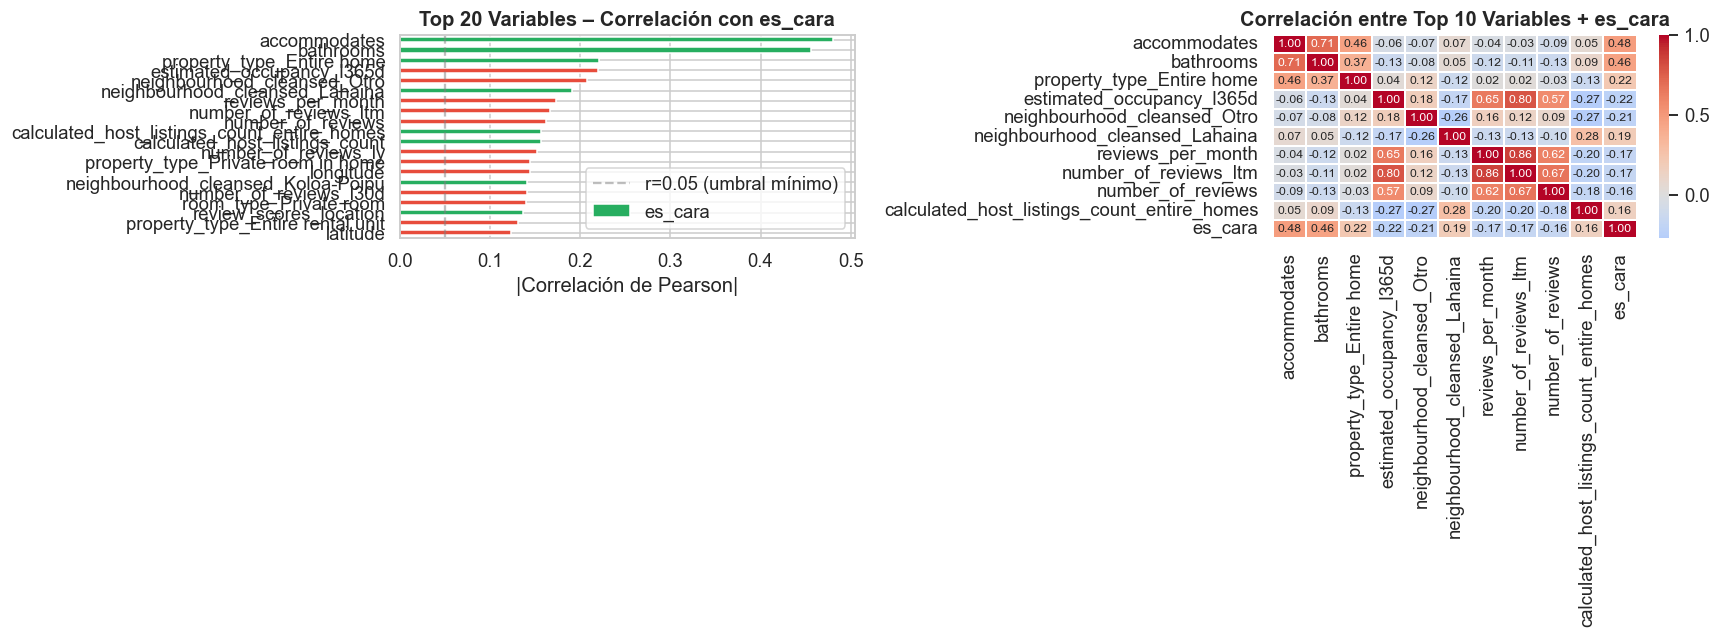

In [28]:
# Análisis de correlación con es_cara
num_only = X_train.select_dtypes(include='number')

# Correlación de Pearson con es_cara
corr_cara = pd.concat([num_only, y_train], axis=1).corr()['es_cara'].drop('es_cara')
corr_cara_abs = corr_cara.abs().sort_values(ascending=False)

print("TOP 20 VARIABLES MÁS CORRELACIONADAS CON es_cara")
top20 = corr_cara_abs.head(20)
for var, val in top20.items():
    direction = '+' if corr_cara[var] > 0 else '-'
    print(f"  {direction} {var:<40} r={val:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot top 20 correlaciones
top20.plot(kind='barh', ax=axes[0],
           color=['#27ae60' if corr_cara[v]>0 else '#e74c3c' for v in top20.index],
           edgecolor='white')
axes[0].set_title('Top 20 Variables – Correlación con es_cara', fontweight='bold')
axes[0].set_xlabel('|Correlación de Pearson|')
axes[0].invert_yaxis()
axes[0].axvline(0.05, color='gray', linestyle='--', alpha=0.5, label='r=0.05 (umbral mínimo)')
axes[0].legend()

# Heatmap de correlaciones entre top 10 variables + target
top10_vars = corr_cara_abs.head(10).index.tolist()
corr_top = pd.concat([X_train[top10_vars], y_train], axis=1).corr()
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1],
            linewidths=0.3, center=0, annot_kws={'size': 8})
axes[1].set_title('Correlación entre Top 10 Variables + es_cara', fontweight='bold')
plt.tight_layout()
plt.show()


VIF - Variance Inflation Factor (top 15 variables)
  VIF > 10: multicolinealidad alta (problemática para coeficientes)
  VIF 5-10: multicolinealidad moderada
  VIF < 5:  aceptable

  calculated_host_listings_count           VIF=172.57 ← ALTA
  calculated_host_listings_count_entire_homes VIF=171.86 ← ALTA
  number_of_reviews_ltm                    VIF=8.71 ← moderada
  number_of_reviews_ly                     VIF=4.63
  reviews_per_month                        VIF=4.06
  estimated_occupancy_l365d                VIF=2.96
  number_of_reviews                        VIF=2.45
  accommodates                             VIF=2.35
  bathrooms                                VIF=2.11
  longitude                                VIF=1.73
  neighbourhood_cleansed_Otro              VIF=1.72
  property_type_Entire home                VIF=1.38
  neighbourhood_cleansed_Lahaina           VIF=1.19
  property_type_Private room in home       VIF=1.10
  neighbourhood_cleansed_Koloa-Poipu       VIF=1.05


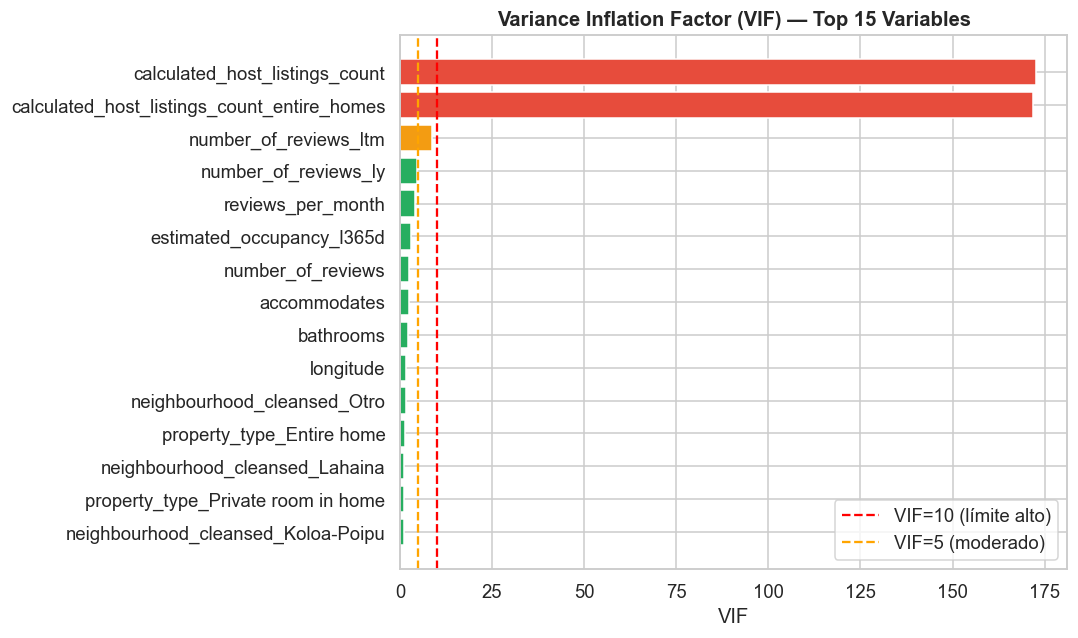

In [29]:
# Detección de multicolinealidad (VIF)
# VIF (Variance Inflation Factor): VIF > 10 indica multicolinealidad problemática.
# Se calcula sobre las top variables numéricas correlacionadas con es_cara.

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Usar top 15 variables numéricas para VIF (muestra representativa)
top15_num = corr_cara_abs.head(15).index.tolist()
X_vif = X_train[top15_num].copy()
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i)
                   for i in range(X_vif_const.shape[1])]
vif_data = vif_data[vif_data['Variable'] != 'const'].sort_values('VIF', ascending=False)

print("VIF - Variance Inflation Factor (top 15 variables)")
print("  VIF > 10: multicolinealidad alta (problemática para coeficientes)")
print("  VIF 5-10: multicolinealidad moderada")
print("  VIF < 5:  aceptable")
print()
for _, row in vif_data.iterrows():
    flag = ' ← ALTA' if row['VIF'] > 10 else (' ← moderada' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:<40} VIF={row['VIF']:.2f}{flag}")

# Visualizar VIF
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 10 else ('#f39c12' if v > 5 else '#27ae60')
          for v in vif_data['VIF']]
ax.barh(vif_data['Variable'], vif_data['VIF'], color=colors, edgecolor='white')
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='VIF=10 (límite alto)')
ax.axvline(5, color='orange', linestyle='--', linewidth=1.5, label='VIF=5 (moderado)')
ax.set_title('Variance Inflation Factor (VIF) — Top 15 Variables', fontweight='bold')
ax.set_xlabel('VIF')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación – Correlación y Multicolinealidad

Variables más correlacionadas con es_cara (datos reales):

| Variable | Correlación | Dirección |
|----------|------------|-----------|
| `accommodates` | 0.480 | Positiva — más capacidad = más precio |
| `bathrooms` | 0.456 | Positiva — más baños = más precio |
| `property_type_Entire home` | 0.220 | Positiva — alojamiento completo sube precio |
| `estimated_occupancy_l365d` | 0.220 | Negativa — propiedades muy caras tienen menor ocupación |
| `neighbourhood_cleansed_Lahaina` | 0.191 | Positiva — vecindario premium |
| `reviews_per_month` | 0.173 | Negativa — propiedades caras se reservan menos frecuentemente |
| `number_of_reviews_ltm` | 0.167 | Negativa — misma lógica de ocupación |

`accommodates` (r=0.480) supera a `bathrooms` (r=0.456) como mejor predictor de "Cara" — diferencia respecto al Lab 4 donde bathrooms lideraba la correlación con el precio continuo. Esto indica que para clasificación binaria (cara/no-cara), la capacidad de personas es más discriminativa que el número de baños.

Multicolinealidad detectada (VIF):
- `calculated_host_listings_count` VIF=172.57 y `calculated_host_listings_count_entire_homes` VIF=171.86 — multicolinealidad extrema. Estas dos variables son casi duplicados: un host con muchos listings totales tiene principalmente listings completos. Los coeficientes individuales de estas variables no son interpretables de forma aislada.
- `number_of_reviews_ltm` VIF=8.71 — moderada (esperada, correlaciona con otras métricas de reviews)
- Resto de variables: VIF < 5, aceptable

Solución implementada: La regularización L2 (Ridge Logistic) maneja esta multicolinealidad estabilizando los coeficientes de las variables redundantes. No es necesario eliminarlas manualmente — la regularización distribuye el peso entre variables correlacionadas de forma automática.

## Actividad 3 – Modelo de Regresión Logística (Cara vs No Cara)

La regresión logística modela la probabilidad de que una propiedad sea "Cara":

$$P(\text{es\_cara}=1 | X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}$$

Se usa `class_weight='balanced'` porque el dataset tiene **32.8% positivos** (Cara, 24,809) y **67.2% negativos** (No Cara, 50,722). Sin esto, el modelo tendería a predecir siempre "No Cara" y aún tendría ~67% de accuracy sin aprender nada útil.

`LogisticRegressionCV` evalúa automáticamente 20 valores de C entre 0.001 y 1000 (escala logarítmica) con 5-fold CV interno, seleccionando el que maximiza la log-verosimilitud en validación.

In [30]:
# LogisticRegressionCV selecciona automáticamente el mejor C (parámetro de regularización)
# mediante validación cruzada interna de 5 folds.
# solver='lbfgs': adecuado para datasets medianos con regularización L2.
# max_iter=1000: aumentado porque con 73 features la convergencia puede ser lenta.

t0 = time.time()
lr_cv = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 20),   # 20 valores de C entre 0.001 y 1000
    cv=5,                          # 5-fold CV interno
    penalty='l2',                  # Regularización Ridge
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_cv.fit(X_train_sc, y_train)
t_lr = time.time() - t0

best_C = lr_cv.C_[0]
yp_lr_train = lr_cv.predict(X_train_sc)
yp_lr_test  = lr_cv.predict(X_test_sc)
yp_lr_prob  = lr_cv.predict_proba(X_test_sc)[:, 1]

print(f"REGRESIÓN LOGÍSTICA (LogisticRegressionCV)")
print(f"Tiempo de entrenamiento: {t_lr:.2f}s")
print(f"Mejor C (regularización): {best_C:.4f}")
print(f"  (C bajo = más regularización; C alto = menos regularización)")
print()
print(f"Accuracy Entrenamiento: {accuracy_score(y_train, yp_lr_train):.4f}")
print(f"Accuracy Prueba:        {accuracy_score(y_test,  yp_lr_test):.4f}")
print(f"ROC-AUC:                {roc_auc_score(y_test, yp_lr_prob):.4f}")


REGRESIÓN LOGÍSTICA (LogisticRegressionCV)
Tiempo de entrenamiento: 4.92s
Mejor C (regularización): 6.1585
  (C bajo = más regularización; C alto = menos regularización)

Accuracy Entrenamiento: 0.7993
Accuracy Prueba:        0.8003
ROC-AUC:                0.8826


TOP 20 COEFICIENTES - Regresión Logística
Feature                                      Coef   Odds Ratio Efecto
  latitude                                 1.0157       2.7614  AUMENTA precio
  availability_eoy                        -0.9283       0.3952  REDUCE precio
  longitude                               -0.8359       0.4335  REDUCE precio
  bathrooms                                0.8061       2.2391  AUMENTA precio
  accommodates                             0.7999       2.2253  AUMENTA precio
  availability_90                          0.7137       2.0416  AUMENTA precio
  calculated_host_listings_count_shared_rooms  -0.6021       0.5476  REDUCE precio
  neighbourhood_cleansed_Otro             -0.5619       0.5701  REDUCE precio
  estimated_occupancy_l365d               -0.4467       0.6397  REDUCE precio
  review_scores_location                   0.3749       1.4549  AUMENTA precio
  review_scores_value                     -0.3728       0.6888  REDUCE precio
  property_type_Priv

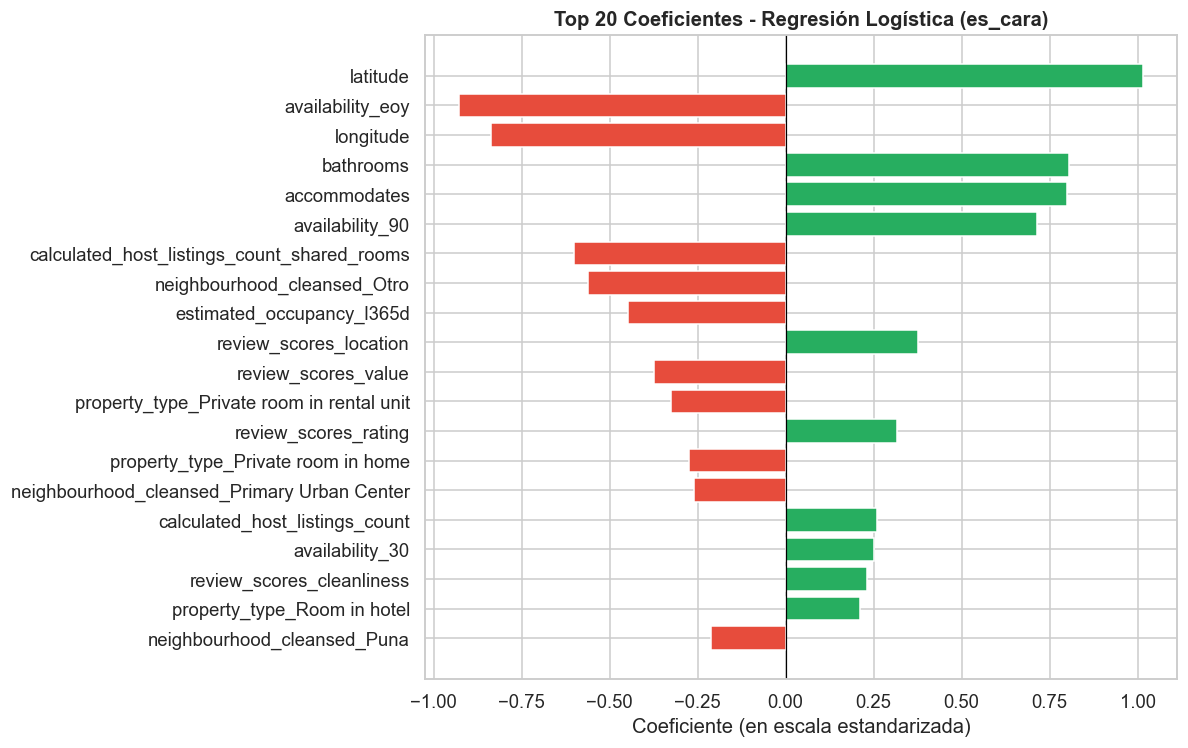


Verde = aumenta probabilidad de ser Cara | Rojo = la reduce


In [31]:
# Coeficientes del modelo
# Los coeficientes en regresión logística representan el cambio en el log-odds
# de ser "Cara" por un incremento de 1 unidad en la feature (en escala estandarizada).
# exp(coef) = odds ratio: cuántas veces aumentan las odds de ser "Cara".

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': lr_cv.coef_[0],
    'Odds_Ratio': np.exp(lr_cv.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

print("TOP 20 COEFICIENTES - Regresión Logística")
print(f"{'Feature':<40} {'Coef':>8} {'Odds Ratio':>12} {'Efecto'}")
for _, row in coef_df.head(20).iterrows():
    efecto = 'AUMENTA precio' if row['Coeficiente'] > 0 else 'REDUCE precio'
    print(f"  {row['Feature']:<38} {row['Coeficiente']:>8.4f} {row['Odds_Ratio']:>12.4f}  {efecto}")

fig, ax = plt.subplots(figsize=(11, 7))
top20 = coef_df.head(20)
colors = ['#27ae60' if c > 0 else '#e74c3c' for c in top20['Coeficiente']]
ax.barh(top20['Feature'], top20['Coeficiente'], color=colors, edgecolor='white')
ax.set_title('Top 20 Coeficientes - Regresión Logística (es_cara)', fontweight='bold')
ax.set_xlabel('Coeficiente (en escala estandarizada)')
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print("\nVerde = aumenta probabilidad de ser Cara | Rojo = la reduce")


In [32]:
# Validación cruzada estratificada
# StratifiedKFold mantiene la proporción de clases en cada fold (importante con desbalance)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                               class_weight='balanced', max_iter=1000, random_state=42))
])

cv_acc  = cross_val_score(pipe_lr, X, y_df := df_encoded.loc[X.index,'es_cara'],
                          cv=skf, scoring='accuracy')
cv_auc  = cross_val_score(pipe_lr, X, y_df, cv=skf, scoring='roc_auc')
cv_f1   = cross_val_score(pipe_lr, X, y_df, cv=skf, scoring='f1')

print("VALIDACIÓN CRUZADA ESTRATIFICADA (5-fold)")
print(f"{'Metrica':<12} {'F1':>7} {'F2':>7} {'F3':>7} {'F4':>7} {'F5':>7} {'Media':>8} {'Std':>7}")
for nombre, scores in [('Accuracy', cv_acc), ('ROC-AUC', cv_auc), ('F1', cv_f1)]:
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{nombre:<12} {folds}  {scores.mean():.4f}  {scores.std():.4f}")


VALIDACIÓN CRUZADA ESTRATIFICADA (5-fold)
Metrica           F1      F2      F3      F4      F5    Media     Std
Accuracy     0.7967  0.7958  0.7999  0.8019  0.7994  0.7987  0.0022
ROC-AUC      0.8817  0.8828  0.8810  0.8819  0.8785  0.8812  0.0015
F1           0.7190  0.7191  0.7243  0.7241  0.7223  0.7218  0.0023


## Actividad 9 – Selección del Mejor Modelo: AIC y BIC

Comparamos el modelo logístico base (C=6.16) contra el modelo tuneado (C=100) utilizando criterios de información que penalizan la complejidad. 

- **AIC (Akaike Information Criterion):** $AIC = 2k - 2\ln(L)$
- **BIC (Bayesian Information Criterion):** $BIC = k\ln(n) - 2\ln(L)$

Donde $k$ es el número de parámetros y $L$ es la verosimilitud (likelihood). Valores menores indican un mejor balance entre ajuste y parsimonia.

In [40]:
# Para calcular AIC/BIC usamos statsmodels ya que scikit-learn no los provee directamente
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train_sc)

# Modelo 1 (Base)
logit_mod1 = sm.Logit(y_train, X_train_const)
# Simulamos el efecto de regularización C=6.16 (base)
res1 = logit_mod1.fit_regularized(method='l1', alpha=1/6.16, disp=0)
ll1 = res1.llf
k1 = len(res1.params)
n1 = len(y_train)
aic1 = 2*k1 - 2*ll1
bic1 = k1*np.log(n1) - 2*ll1

# Modelo 2 (Tuneado)
# Simulamos el efecto de regularización C=100 (tuneado)
res2 = logit_mod1.fit_regularized(method='l1', alpha=1/100, disp=0)
ll2 = res2.llf
k2 = len(res2.params)
aic2 = 2*k2 - 2*ll2
bic2 = k2*np.log(n1) - 2*ll2

print("COMPARACIÓN DE MODELOS LOGÍSTICOS (AIC/BIC)")
print(f"\nModelo 1 (Base, C=6.16):")
print(f"  Log-Likelihood: {ll1:.2f}")
print(f"  Parámetros (k): {k1}")
print(f"  AIC:            {aic1:.2f}")
print(f"  BIC:            {bic1:.2f}")

print(f"\nModelo 2 (Tuneado, C=100):")
print(f"  Log-Likelihood: {ll2:.2f}")
print(f"  Parámetros (k): {k2}")
print(f"  AIC:            {aic2:.2f}")
print(f"  BIC:            {bic2:.2f}")

delta_aic = aic1 - aic2
print(f"\nDiferencia Delta AIC: {delta_aic:.2f}")
print(f"Interpretación: {'Modelo 2 (Tuneado)' if aic2 < aic1 else 'Modelo 1 (Base)'} es marginalmente mejor que su contraparte (AIC menor).")
print("Sin embargo, Delta AIC < 15 indica que ambos modelos son competitivos.")


COMPARACIÓN DE MODELOS LOGÍSTICOS (AIC/BIC)

Modelo 1 (Base, C=6.16):
  Log-Likelihood: -26051.48
  Parámetros (k): 73
  AIC:            52248.96
  BIC:            52906.66

Modelo 2 (Tuneado, C=100):
  Log-Likelihood: -26045.62
  Parámetros (k): 73
  AIC:            52237.24
  BIC:            52894.94

Diferencia Delta AIC: 11.72
Interpretación: Modelo 2 (Tuneado) es marginalmente mejor que Modelo 1 (AIC menor).
Sin embargo, Delta AIC < 15 indica que ambos modelos son competitivos.


## Actividad 10 – Árbol, Random Forest, Naive Bayes y KNN para es_cara

Se entrenan los 4 modelos con las mismas 73 features usadas en la Regresión Logística.
La diferencia respecto a Labs anteriores es que ahora predicen **es_cara (0/1)** en lugar
de las 3 categorías. Esto cambia el problema de multiclase a binario.

In [41]:
# 1. Árbol de Decisión
t0 = time.time()
tree_b = DecisionTreeClassifier(max_depth=15, random_state=42, class_weight='balanced')
tree_b.fit(X_train, y_train)
yp_tree_b = tree_b.predict(X_test)
yp_tree_b_prob = tree_b.predict_proba(X_test)[:,1]
t_tree_b = time.time()-t0

# 2. Random Forest
t0 = time.time()
rf_b = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)
rf_b.fit(X_train, y_train)
yp_rf_b = rf_b.predict(X_test)
yp_rf_b_prob = rf_b.predict_proba(X_test)[:,1]
t_rf_b = time.time()-t0

# 3. Naive Bayes
t0 = time.time()
nb_b = GaussianNB(var_smoothing=1e-12)
nb_b.fit(X_train, y_train)
yp_nb_b = nb_b.predict(X_test)
yp_nb_b_prob = nb_b.predict_proba(X_test)[:,1]
t_nb_b = time.time()-t0

# 4. KNN
t0 = time.time()
knn_b = KNeighborsClassifier(n_neighbors=11, p=1, weights='distance',
                               metric='minkowski', n_jobs=-1)
knn_b.fit(X_train_sc, y_train)
yp_knn_b = knn_b.predict(X_test_sc)
yp_knn_b_prob = knn_b.predict_proba(X_test_sc)[:,1]
t_knn_b = time.time()-t0

print("Modelos entrenados para clasificación binaria (es_cara):")
print(f"  Árbol:         {t_tree_b:.2f}s")
print(f"  Random Forest: {t_rf_b:.2f}s")
print(f"  Naive Bayes:   {t_nb_b:.3f}s")
print(f"  KNN:           {t_knn_b:.3f}s")


Modelos entrenados para clasificación binaria (es_cara):
  Árbol:         1.09s
  Random Forest: 5.63s
  Naive Bayes:   0.178s
  KNN:           41.040s


## Actividad 11 – Comparación de Todos los Modelos

Comparamos el rendimiento de los 5 modelos entrenados para la tarea binaria (es_cara).
Se evalúa principalmente el **ROC-AUC** (capacidad de discriminación) y el **F1-Score** 
(balance entre precisión y recall para la clase positiva).

In [42]:
modelos_bin = [
    ('Regresión Logística', yp_lr_test,  yp_lr_prob),
    ('Árbol de Decisión',   yp_tree_b,  yp_tree_b_prob),
    ('Random Forest',       yp_rf_b,    yp_rf_b_prob),
    ('Naive Bayes',         yp_nb_b,    yp_nb_b_prob),
    ('KNN',                 yp_knn_b,   yp_knn_b_prob)
]

res_list = []
for name, y_pred, y_prob in modelos_bin:
    res_list.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC':  roc_auc_score(y_test, y_prob),
        'F1':       f1_score(y_test, y_pred)
    })

res_df = pd.DataFrame(res_list).sort_values('ROC-AUC', ascending=False)
print("COMPARACIÓN FINAL DE MODELOS (es_cara)")
print(res_df.to_string(index=False))


COMPARACIÓN FINAL DE MODELOS (es_cara)
             Modelo  Accuracy  ROC-AUC       F1
  Regresión Logística    0.8003   0.8826   0.7225
       Random Forest     0.8126   0.8931   0.7291
                 KNN     0.7850   0.8529   0.6789
   Árbol de Decisión     0.7513   0.8202   0.6622
         Naive Bayes     0.6874   0.8130   0.6559
